# Modelo de predicción de *silent churn* — Glamour Perú

**Versión del dataset**: v5 (vigente)
**Modelo**: `HistGradientBoostingClassifier` con `class_weight='balanced'`
**Granularidad**: una fila por (vendedora, mes calendario)
**Horizonte de predicción**: 6 meses

---

Este notebook aplica la **mejor configuración encontrada** durante la fase
exploratoria (notebooks 01-08, ver `VERSIONES.md`) y la presenta como un
documento autocontenido. Está pensado para ser leído por alguien que no
tiene formación profunda en *machine learning*: cada bloque de código va
precedido por un marco teórico que explica **qué se está haciendo y por
qué**.

> Si querés ver el camino exploratorio que llevó a estas decisiones, mirá
> los notebooks 01–08 en `notebooks/drafts/`. Acá no se vuelven a
> justificar las decisiones, sólo se aplican.


# Parte 0 — Marco teórico

Antes de tocar código conviene fijar el vocabulario. Esta sección no
contiene operaciones — sólo conceptos. Si ya conocés ML clásico, podés
saltearla.


## 0.1 ¿Qué es *churn* y por qué es difícil de definir?

**Churn** (literalmente "fuga") es el término genérico para clientes que
dejan de comprar / usar un servicio. En telcos, banca o streaming la fuga
es **explícita**: el cliente da de baja su línea o cancela su suscripción.
En **venta directa** (Avon, Natura, Glamour) **no hay baja formal**: una
vendedora simplemente deja de hacer pedidos. Eso se llama *silent churn*.

El problema metodológico: **¿cuándo decimos que ya churneó?** Si esperamos
1 mes podemos confundir vacaciones con baja. Si esperamos 12 meses la
señal llega tarde para cualquier acción de retención.

En este proyecto se eligió el siguiente compromiso operativo:

> **Una vendedora churnea en el mes _M_ si no compra en _ninguno_ de los
> 6 meses calendario siguientes (_M+1_ … _M+6_).**

El número 6 no es arbitrario: el análisis del notebook
`06_horizonte_v4.ipynb` muestra que después de 6 meses sin compra la
probabilidad mensual de retorno cae por debajo del 6% (queda muy chata),
así que pasados esos 6 meses lo que veamos es ruido, no recuperación
genuina. Antes de esos 6 meses todavía hay vendedoras esporádicas
legítimas que vuelven.


## 0.2 Aprendizaje supervisado en una frase

> **Aprendizaje supervisado** = darle a una máquina muchos ejemplos de
> entrada/salida correctos para que aprenda a generalizar a entradas
> nuevas.

En nuestro caso:

- **Entrada (X)**: las características de una vendedora en un mes dado
  (cuánto compró últimamente, hace cuántos meses fue su última compra,
  qué ticket promedio tiene, etc.).
- **Salida (y)**: 0 si **NO** churnea en los próximos 6 meses, 1 si
  churnea.
- **El modelo** observa miles de filas (X, y) del pasado y "aprende" qué
  patrones de X tienden a ir con y=1.

A esto se le llama **clasificación binaria**: la salida es una de dos
categorías.

> **Importante**: el modelo no devuelve sólo un 0 o un 1. Devuelve una
> **probabilidad** P(churn=1) entre 0 y 1. Para decidir si "marco como
> churn" o no, hay que elegir un **umbral** (threshold). Por defecto se
> usa 0.5, pero ese umbral es ajustable según el costo de equivocarse
> en cada lado (ver Parte 6).


## 0.3 ¿Qué es un *panel longitudinal*?

La granularidad estándar en proyectos de churn es *una fila por cliente*.
Acá la elegimos distinta: **una fila por (vendedora, mes)**. Para una
vendedora con 18 meses de historia activa hay 18 filas distintas.

Esto se llama **panel longitudinal** o panel de datos. Tiene dos ventajas:

1. **Multiplica la muestra** efectiva (≈24 mil filas vs ≈3 mil
   vendedoras únicas).
2. Cada fila representa una **decisión de scoring real**: "en el mes
   _M_, dado lo que sé hasta el mes _M_, ¿esta vendedora churneará?".
   Es exactamente el escenario de producción.

La desventaja: las filas de la **misma vendedora** están **correlacionadas
entre sí**. Hay que tener cuidado al validar (ver 0.5).


## 0.4 Las features: el patrón **RFM**

El feature engineering del SQL sigue el patrón clásico **RFM**, que viene
del marketing relacional:

- **R**ecency (recencia): hace cuántos meses fue su última compra
  (`meses_desde_compra_previa`).
- **F**requency (frecuencia): cuántas veces compró en una ventana
  (`num_compras_u3`, `num_compras_u6`, `num_compras_u12` — últimos 3, 6,
  12 meses respectivamente).
- **M**onetary (monetario): cuánto gastó en cada ventana
  (`monto_total_u3`, `monto_pagado_u6`, etc.).

A estas tres familias se le suman:

- **Tendencias normalizadas en [-1, 1]** (`delta_*_u3_vs_prev3`): mide si
  la vendedora viene aumentando o reduciendo su actividad. La fórmula es
  `(u3 - prev3) / (u3 + prev3)`.
- **Diversidad de producto** (`avg_categorias_u6`,
  `num_productos_distintos`).
- **Contexto** (departamento, tipo de vendedora, antigüedad,
  coordinadora).

La intuición: **una vendedora que está churneando muestra primero una
caída en F y M, mientras R crece** (el gap desde la última compra se
hace cada vez mayor). El modelo va a redescubrir esa intuición a partir
de los datos.


## 0.5 Validación: ¿por qué hay que dividir los datos?

Si entrenamos y evaluamos sobre el mismo conjunto, el modelo puede
**memorizar** y reportar un AUC altísimo que no se sostiene en
producción. Por eso siempre se separa en:

- **Train**: lo que el modelo ve para aprender.
- **Test (hold-out)**: lo que el modelo NO ve, usado solo para reportar
  la métrica.

En este proyecto usamos **dos protocolos complementarios**:

### Protocolo A — `GroupKFold` por vendedora (5 folds)

> **Idea**: dividir las vendedoras en 5 grupos. En cada iteración usamos
> 4 grupos para entrenar y 1 para evaluar. Rotamos las 5 veces y
> promediamos. **Una vendedora nunca está al mismo tiempo en train y en
> test.**

Esto es importante porque si María tiene 10 filas y 7 caen en train + 3
en test, el modelo **reconoce a María** por sus rasgos fijos
(departamento, edad, coordinadora) y reporta una métrica falsamente
optimista. Con `GroupKFold` por `id_vendedor`, María cae **toda en un
solo lado**, y la métrica mide capacidad de **generalizar a vendedoras
nunca vistas**.

Esta es la **métrica honesta** y la principal que vamos a reportar.

### Protocolo B — Split temporal *forward*

> **Idea**: entrenar con todos los meses **hasta** un punto de corte y
> evaluar sobre los meses **posteriores**. Simula el escenario real:
> "entrenar hoy con histórico, predecir mañana".

Detalle técnico: dejamos un **GAP** de `horizonte + 1 = 7` meses entre el
último mes de train y el primero de test. Por qué: el target del último
mes de train mira los 6 meses siguientes; si test empieza dentro de esa
ventana, las features de test "saben" cosas que el target del último
train aún no terminaba de definir. El gap evita ese solapamiento.

Reportamos también el **AUC mes a mes dentro del bloque test** (su
desviación estándar mide la **estabilidad temporal** del modelo).


## 0.6 Métricas

Para clasificación binaria con clases desbalanceadas (acá hay ~27%
positivos), las métricas relevantes son:

### AUC ROC — *Area Under the ROC Curve*

> **Pregunta que responde**: si tomo al azar una vendedora que churneó y
> una que no, ¿con qué probabilidad el modelo le asigna una P(churn=1)
> mayor a la primera?

- AUC = 0.5 → el modelo no distingue (azar puro).
- AUC = 1.0 → separa perfectamente.
- AUC = 0.75 → en el 75% de los pares "churner vs no-churner", el modelo
  ranquea correctamente.

Es **independiente del threshold**: mide la capacidad de **ordenar**
clientes por riesgo, no la calidad de una decisión 0/1 puntual.

### PR-AUC — *Area Under the Precision-Recall Curve*

Más informativa que AUC ROC cuando hay desbalance fuerte. Lo que
importa acá no es el valor absoluto sino el **lift sobre la prevalencia**
(qué tan mejor que el azar es). Si la prevalencia es 27.5% y el modelo
saca PR-AUC 0.50, el lift es ≈1.84× (el modelo es 84% mejor que
predecir aleatorio).

### Matriz de confusión, precision, recall, F1

Una vez fijado un threshold, cada predicción cae en uno de cuatro
casilleros:

|  | Predicho 0 (no-churn) | Predicho 1 (churn) |
|---|---|---|
| **Real 0** | TN (verdadero negativo) | FP (falso positivo) |
| **Real 1** | FN (falso negativo) | TP (verdadero positivo) |

- **Precision** = TP / (TP + FP). De los que el modelo marcó como
  churners, ¿qué fracción realmente lo es?
- **Recall** = TP / (TP + FN). De los churners reales, ¿qué fracción
  agarró el modelo?
- **F1** = media armónica de precision y recall (un solo número
  resumen).

Hay un **trade-off**: subir el threshold ⇒ más precision, menos recall.
Bajarlo ⇒ menos precision, más recall. La elección depende del **costo
de negocio**: ¿es más caro perder una churner real (FN) o molestar a una
no-churner con una intervención innecesaria (FP)?


## 0.7 Anti-leakage: las trampas que ya están resueltas

**Leakage** = información del futuro filtrándose en las features y
inflando la métrica. En este proyecto se atacaron tres:

1. **Variables del horizonte como features** (`compro_t1..t6` en v2): un
   modelo que ve `compro_t3` como feature ya conoce parte del target
   directamente. Resuelto desde v3 (esas columnas se eliminaron).

2. **Misma vendedora en train y test**: resuelto con `GroupKFold` por
   `id_vendedor`.

3. **Solapamiento de horizonte en split temporal**: resuelto con el GAP
   de 7 meses (ver 0.5).

Con estas tres salvaguardas, las métricas reportadas acá son honestas y
representativas de lo que veríamos en producción.


# Parte 1 — Carga del dataset v5

El dataset vive en BigQuery (`glamour-peru-dw.glamour_dw.training_churn_v5`)
y se construye con `data/qry_churn_v5.sql`. Esta query aplica **todos los
filtros de población** (compras_historicas ≥ 3, churn no nulo, mes con
compra) — el DataFrame que carguemos ya está listo para entrenar.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
np.random.seed(42)

# Constantes del proyecto (no tocar — vienen de las decisiones de diseño)
PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
TABLE = f'`{PROJECT}.{DATASET}.training_churn_v5`'
RANDOM_STATE = 42
N_SPLITS = 5            # folds del GroupKFold
HORIZON_CHURN = 6       # meses (definición del target)
TEST_WINDOW = 6         # tamaño del bloque test en el split forward
GAP = HORIZON_CHURN + 1 # = 7 meses, ver Parte 0.5


In [2]:
bq = bigquery.Client(project=PROJECT)
df = bq.query(f'SELECT * FROM {TABLE}').to_dataframe()

print(f'Filas              : {len(df):,}')
print(f'Vendedoras únicas  : {df["id_vendedor"].nunique():,}')
print(f'Meses cubiertos    : {df["mes_obs"].nunique()}')
print(f'Rango temporal     : {df["mes_obs"].min()} → {df["mes_obs"].max()}')
print(f'Tasa de churn      : {df["churn"].mean():.4f}  ({df["churn"].sum():,} positivos)')
print()
print('Primeras 3 filas:')
df.head(3)


Filas              : 23,684
Vendedoras únicas  : 4,211
Meses cubiertos    : 106
Rango temporal     : 2017-01-01 → 2025-10-01
Tasa de churn      : 0.2750  (6,514 positivos)

Primeras 3 filas:


,id_vendedor,mes_obs,mes_rank_obs,anio_mes_num,mes_num,fecha_ingreso,edad_vendedor,sexo_vendedor,tipo_vendedor,ccodrelacion,antiguedad_meses,id_coordinadora,edad_coordinadora,ccodubigeo,distrito,provincia,departamento,num_pedidos_obs,monto_total_obs,monto_pagado_obs,num_categorias_obs,num_productos_obs,num_compras_u3,monto_total_u3,monto_pagado_u3,tasa_compra_u3,ticket_promedio_u3,ratio_pago_u3,num_compras_u6,monto_total_u6,monto_pagado_u6,tasa_compra_u6,ticket_promedio_u6,ratio_pago_u6,num_compras_u12,monto_total_u12,monto_pagado_u12,tasa_compra_u12,ticket_promedio_u12,ratio_pago_u12,avg_categorias_u6,avg_productos_u6,unidades_u6,meses_desde_compra_previa,compras_historicas,monto_historico,delta_monto_u3_vs_prev3,delta_compras_u3_vs_prev3,ticket_u3_vs_u12,churn
0,19733399,2020-07-01,45,2020,7,2019-01-07,NaN,F,Asesora,19729280,19,19721983,47.0,PE120014,chanchamayo,chanchamayo,junin,1,406.93,294.85,3,7,1,406.93,294.85,0.333333,406.93,0.724572,1,406.93,294.85,0.166667,406.93,0.724572,7,2774.61,2015.30,0.583333,396.372857,0.726336,0.500000,1.166667,9.0,6,12,5104.23,1.0,1.0,1.026634,1
1,19735748,2020-07-01,45,2020,7,2019-10-16,NaN,F,Asesora,0,10,19721986,47.0,PE150037,santa anita,lima,lima,1,180.00,195.00,1,1,1,180.00,195.00,0.333333,180.00,1.083333,1,180.00,195.00,0.166667,180.00,1.083333,4,797.91,678.44,0.400000,199.477500,0.850271,0.166667,0.166667,3.0,6,4,797.91,1.0,1.0,0.902357,1
2,19724047,2020-07-01,45,2020,7,2016-12-11,NaN,F,Asesora,19722045,43,19721983,47.0,PE130077,trujillo,trujillo,la libertad,1,281.96,202.37,1,5,1,281.96,202.37,0.333333,281.96,0.717726,1,281.96,202.37,0.166667,281.96,0.717726,3,1078.85,775.20,0.250000,359.616667,0.718543,0.166667,0.833333,5.0,6,14,14399.65,1.0,1.0,0.784057,0


**Lectura rápida**:

- ~24 mil filas / ~3 mil vendedoras → en promedio cada vendedora aporta
  ≈8 meses de panel.
- Tasa de churn del 27.5% (clases moderadamente desbalanceadas — no es
  un caso extremo como fraude con 1% positivos, pero tampoco está al
  50/50).
- El rango temporal cubre varios años, lo que nos da margen para el
  split forward.


# Parte 2 — Preparación de features

## 2.1 Marco teórico: ¿qué es un *pipeline* de preprocesamiento?

Un modelo de scikit-learn no acepta cualquier DataFrame. Espera:

- **Sólo números** — los strings ("Lima", "Veterana") deben convertirse
  a representación numérica.
- **Sin valores faltantes** (NaN) — al menos para los modelos que no los
  manejan nativamente.

El **pipeline** es una cadena de transformaciones que se aplica
**siempre igual** en train y en test. Eso es crítico: si en test
imputamos los NaN con números distintos a train, el modelo va a ver
distribuciones distintas y a fallar.

Las dos transformaciones que vamos a aplicar:

1. **Imputación**: reemplazar NaN por la mediana (numéricas) o por la
   string `'NA'` (categóricas).
2. **One-Hot Encoding**: para variables categóricas como
   `departamento`, crea una columna binaria por cada valor único. Si
   `departamento` toma 25 valores → 25 columnas booleanas, exactamente
   una de ellas en 1 por fila.

`HistGradientBoosting` (nuestro modelo final) maneja NaN nativamente,
así que la imputación es por consistencia con otros experimentos. La
parte importante es el one-hot.


## 2.2 Selección de columnas

Excluimos columnas que **no deben** entrar al modelo:

| Columna | Razón de exclusión |
|---|---|
| `id_vendedor` | Identificador. Si lo dejamos, el modelo memoriza vendedoras. |
| `mes_obs`, `mes_rank_obs` | Trazabilidad temporal, no es feature. |
| `fecha_ingreso` | Fecha cruda; su señal ya está en `antiguedad_meses`. |
| `id_coordinadora` | Identificador de alta cardinalidad. |
| `ccodrelacion` | Identificador (relación quien-recomendó-a-quien). Apareció top-4 en permutación pero no es señal de comportamiento — el modelo se estaría apoyando en un ID. |
| `ccodubigeo`, `distrito` | Cardinalidad ~cientos → riesgo de ID disfrazado. Usamos `provincia` y `departamento` que tienen menos categorías. |
| `mes_num`, `anio_mes_num` | Features de calendario. El ablation (`ablation_temporal_v5.ipynb`) mostró que en split forward (escenario de producción) el modelo es **igual o mejor** sin ellas: PR-AUC sube +4.6%. `anio_mes_num` además toma valores fuera del rango de train en producción → riesgo de extrapolación. |
| `churn` | Es el target, no una feature. |


In [3]:
EXCLUDE = {
    'id_vendedor', 'mes_obs', 'mes_rank_obs',
    'fecha_ingreso',
    'id_coordinadora', 'ccodrelacion', 'ccodubigeo', 'distrito',
    'mes_num', 'anio_mes_num',   # ver ablation_temporal_v5.ipynb
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']

feature_cols = [c for c in df.columns if c not in EXCLUDE]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

# Las categóricas pueden venir con NaN: las pasamos a string y rellenamos con 'NA'
for c in CATEGORICAL:
    df[c] = df[c].astype('string').fillna('NA')

X = df[feature_cols].copy()
y = df['churn'].astype(int).values
groups = df['id_vendedor'].values   # se usa en GroupKFold

print(f'Total de features    : {len(feature_cols)}')
print(f'  - numéricas        : {len(numeric_cols)}')
print(f'  - categóricas      : {len(CATEGORICAL)}')
print()
print('Cardinalidad de las categóricas:')
for c in CATEGORICAL:
    print(f'  {c:<20} {X[c].nunique():>4} valores únicos')
print()
print(f'Distribución del target:')
print(f'  no-churn (0) : {(y==0).sum():>6,}  ({(y==0).mean()*100:5.2f}%)')
print(f'  churn    (1) : {(y==1).sum():>6,}  ({(y==1).mean()*100:5.2f}%)')


Total de features    : 39
  - numéricas        : 35
  - categóricas      : 4

Cardinalidad de las categóricas:
  sexo_vendedor           4 valores únicos
  tipo_vendedor           2 valores únicos
  departamento           32 valores únicos
  provincia             152 valores únicos

Distribución del target:
  no-churn (0) : 17,170  (72.50%)
  churn    (1) :  6,514  (27.50%)


## 2.3 Construcción del pipeline


In [4]:
def build_preprocessor() -> ColumnTransformer:
    """Numéricas: imputar mediana. Categóricas: rellenar 'NA' y one-hot."""
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])

# Quick check del pipeline (no entrena nada todavía)
preproc = build_preprocessor()
X_transformed = preproc.fit_transform(X.head(100))
print(f'Antes  : {X.head(100).shape}  → 53 columnas mezcladas')
print(f'Después: {X_transformed.shape}  → todo numérico, una col por categoría one-hot')


Antes  : (100, 39)  → 53 columnas mezcladas
Después: (100, 107)  → todo numérico, una col por categoría one-hot


# Parte 3 — Modelo: HistGradientBoosting

## 3.1 De los árboles de decisión al *gradient boosting*

### Árbol de decisión

Un **árbol de decisión** es la estructura más simple e interpretable de
la familia. Hace preguntas binarias en cascada:

```
                ¿meses_desde_compra_previa > 3?
                /                              \
              Sí                                No
              /                                  \
   ¿num_compras_u6 < 2?              ¿tasa_compra_u12 < 0.4?
       /         \                       /              \
   churn        no-churn              churn          no-churn
```

Una hoja del árbol predice una probabilidad calculada como el
porcentaje de churners entre los datos de entrenamiento que cayeron en
esa hoja. Un solo árbol es **fácil de leer** pero **frágil**: cambia
mucho con datos distintos.

### Ensemble: muchos árboles

Un **ensemble** combina muchos árboles. La predicción final es la
combinación (promedio, voto, suma ponderada) de las de cada árbol
individual.

### Gradient boosting

> **Idea clave del *boosting***: entrenar árboles **secuencialmente**,
> donde cada árbol nuevo se concentra en **corregir los errores** de
> la suma de los anteriores.

Más formal: el modelo final es

```
F(x) = árbol_1(x) + lr · árbol_2(x) + lr · árbol_3(x) + ...
```

donde `lr` (*learning rate*) es un factor pequeño (en este modelo,
0.05) que limita cuánto puede corregir cada árbol nuevo. Se entrenan
iterativamente: el árbol _k_ aprende a predecir el **gradiente del
error** de los _k-1_ anteriores, de ahí el nombre *gradient boosting*.

### `HistGradientBoosting`: la versión rápida

Es la implementación de scikit-learn equivalente a LightGBM. La "Hist"
viene de que **discretiza los valores numéricos en histogramas** (256
*bins* por feature) en lugar de buscar el split óptimo sobre todos los
valores. Eso lo hace **muy rápido** sin sacrificar mucha calidad. Otra
ventaja crítica: **acepta NaN nativamente** sin imputación.


## 3.2 ¿Por qué este modelo y no otro?

Durante la fase exploratoria (NB 03 sobre v3, NB 05 sobre v4, NB 07
sobre v5) se compararon 6 modelos en igualdad de condiciones:

| Modelo | AUC GroupKFold (v5) | Comentario |
|---|---:|---|
| Dummy (predice al azar) | 0.50 | Piso teórico |
| Heurística "gap previo" | 0.66 | `1 - exp(-gap/6)` — sin entrenar |
| LogReg (balanced) | 0.74 | Lineal, simple, interpretable |
| **HGB (balanced)** | **0.7465** | **Ganador** |
| LightGBM (unbalanced) | 0.74 | Empate técnico con HGB |
| XGBoost (scale_pos_weight) | 0.74 | Empate técnico con HGB |

HGB ganó por **margen pequeño pero consistente** y tiene una ventaja
operativa: viene en el core de scikit-learn (no requiere instalar
LightGBM/XGBoost ni dependencias nativas como `libomp`).

## 3.3 ¿Qué hace `class_weight='balanced'`?

El dataset tiene 27.5% de churners. Sin ningún ajuste, el modelo aprende
implícitamente que "el caso típico es no-churn" y se vuelve conservador:
predice probabilidades chicas en general y se pierde recall.

`class_weight='balanced'` le dice al modelo que **pese cada churner
~2.6× más** que cada no-churner durante el entrenamiento (la fórmula
exacta es `n / (2 * count(clase))`, lo que iguala el "peso total" de
ambas clases). Resultado: el modelo es más sensible a los positivos —
pierde algo de precision y gana mucho recall.

## 3.4 Hiperparámetros tuneados (ver `tuning_optuna_v5.ipynb`)

Los valores de `learning_rate`, `max_iter`, `max_depth`, etc., no son
defaults — provienen de un tuning con Optuna (50 trials, sampler TPE)
detallado en `tuning_optuna_v5.ipynb`. La búsqueda mostró que:

- `learning_rate` explica el **79%** de la varianza del AUC durante
  la búsqueda → es la palanca dominante.
- El óptimo combina **learning rate bajo + muchos árboles + hojas
  grandes** — receta clásica de boosting estable.
- La ganancia respecto del default es +1.2 pp en GroupKFold y
  +0.8 pp en split forward, con el modelo además **más estable**
  (std entre folds bajó 18%).


In [5]:
def make_hgb() -> Pipeline:
    """Pipeline final: HGB balanceado con hiperparámetros tuneados (Optuna)."""
    return Pipeline([
        ('prep', build_preprocessor()),
        ('clf', HistGradientBoostingClassifier(
            class_weight='balanced',
            learning_rate=0.0175,       # tuneado (default 0.1)
            max_iter=750,               # tuneado (default 100)
            max_depth=4,                # tuneado (default None)
            max_leaf_nodes=22,          # tuneado (default 31)
            min_samples_leaf=100,       # tuneado (default 20)
            l2_regularization=0.0,      # tuneado (default 0.0)
            random_state=RANDOM_STATE,
            early_stopping=False,
        )),
    ])

print('Pipeline definido (todavía no entrenado).')
print(make_hgb())


Pipeline definido (todavía no entrenado).
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['edad_vendedor',
                                                   'antiguedad_meses',
                                                   'edad_coordinadora',
                                                   'num_pedidos_obs',
                                                   'monto_total_obs',
                                                   'monto_pagado_obs',
                                                   'num_categorias_obs',
                                                   'num_productos_obs',
                                                   'num_compras_u3',
                                                   'monto_total_u3',
                                                   'monto_pagado_u3',
                 

# Parte 4 — Validación 1: `GroupKFold` por vendedora

## 4.1 Recordatorio teórico

`GroupKFold` divide las **vendedoras** (no las filas) en _N_ grupos
disjuntos. En este proyecto _N_ = 5.

Iteración _i_:
1. **Train** = 4 grupos, **Test** = 1 grupo (vendedoras nunca antes
   vistas por el modelo).
2. Entrenar el pipeline sobre train.
3. Predecir P(churn=1) sobre test.
4. Calcular AUC y PR-AUC del fold.

Después de las 5 iteraciones se promedian las métricas y se concatenan
las predicciones (a esto se le llama **OOF** = *out-of-fold*).

> **Garantía clave**: cada fila de test tiene su predicción generada por
> un modelo que **nunca vio a esa vendedora durante entrenamiento**.
> Eso hace que la métrica sea honesta.


In [6]:
cv = GroupKFold(n_splits=N_SPLITS)

# Sanity check: ningún id_vendedor aparece en train Y test simultáneamente
for fold_i, (tr, te) in enumerate(cv.split(X, y, groups), 1):
    overlap = set(groups[tr]) & set(groups[te])
    assert not overlap, f'fold {fold_i}: leakage de vendedora detectado'
print(f'OK — GroupKFold con {N_SPLITS} folds, sin solapamiento de vendedoras.')
print()
for fold_i, (tr, te) in enumerate(cv.split(X, y, groups), 1):
    print(f'  Fold {fold_i}: train {len(tr):>5,} filas / {len(set(groups[tr])):>4} vendedoras  '
          f'· test {len(te):>5,} / {len(set(groups[te])):>4}')


OK — GroupKFold con 5 folds, sin solapamiento de vendedoras.

  Fold 1: train 18,947 filas / 3369 vendedoras  · test 4,737 /  842
  Fold 2: train 18,947 filas / 3369 vendedoras  · test 4,737 /  842
  Fold 3: train 18,947 filas / 3369 vendedoras  · test 4,737 /  842
  Fold 4: train 18,947 filas / 3368 vendedoras  · test 4,737 /  843
  Fold 5: train 18,948 filas / 3369 vendedoras  · test 4,736 /  842


## 4.2 Entrenamiento y evaluación

Esto entrena el pipeline 5 veces (una por fold). Tarda ≈30 segundos en
una laptop razonable.


In [7]:
oof_proba = np.zeros(len(y), dtype=float)
fold_aucs, fold_aps = [], []

for fold_i, (tr, te) in enumerate(cv.split(X, y, groups), 1):
    model = make_hgb()
    model.fit(X.iloc[tr], y[tr])
    proba_te = model.predict_proba(X.iloc[te])[:, 1]
    oof_proba[te] = proba_te

    auc = roc_auc_score(y[te], proba_te)
    ap  = average_precision_score(y[te], proba_te)
    fold_aucs.append(auc); fold_aps.append(ap)
    print(f'  Fold {fold_i}:  AUC = {auc:.4f}   PR-AUC = {ap:.4f}')

auc_mean = np.mean(fold_aucs); auc_std = np.std(fold_aucs)
ap_mean  = np.mean(fold_aps);  ap_std  = np.std(fold_aps)
auc_oof  = roc_auc_score(y, oof_proba)
ap_oof   = average_precision_score(y, oof_proba)
prev     = y.mean()

print()
print(f'AUC fold (mean ± std) : {auc_mean:.4f} ± {auc_std:.4f}')
print(f'AUC OOF (concatenado) : {auc_oof:.4f}')
print(f'PR-AUC fold (mean±std): {ap_mean:.4f} ± {ap_std:.4f}')
print(f'PR-AUC OOF            : {ap_oof:.4f}   (prevalencia {prev:.4f}, lift {ap_oof/prev:.2f}×)')


  Fold 1:  AUC = 0.7526   PR-AUC = 0.5142


  Fold 2:  AUC = 0.7450   PR-AUC = 0.5069


  Fold 3:  AUC = 0.7539   PR-AUC = 0.4998


  Fold 4:  AUC = 0.7342   PR-AUC = 0.4856


  Fold 5:  AUC = 0.7570   PR-AUC = 0.5109

AUC fold (mean ± std) : 0.7485 ± 0.0082
AUC OOF (concatenado) : 0.7484
PR-AUC fold (mean±std): 0.5035 ± 0.0101
PR-AUC OOF            : 0.5020   (prevalencia 0.2750, lift 1.83×)


**Cómo leer estos números**:

- **AUC ≈ 0.74-0.75**: el modelo separa razonablemente bien. Para un
  problema de churn en venta directa con definición silenciosa, este
  nivel es coherente con la literatura (telcos llegan a 0.85+ porque
  el churn ahí es explícito y los datos más limpios).
- **Std entre folds < 0.01**: el modelo es **estable**. Si el std fuera
  0.05+, querría decir que la performance depende mucho de qué subset
  de vendedoras toque, lo cual sería preocupante.
- **Lift PR-AUC ≈ 1.85×**: el modelo es ~85% mejor que predecir al azar
  ponderado por prevalencia. Es un lift sólido pero no espectacular.


## 4.3 Curvas ROC y Precision-Recall

Las dos curvas estándar para visualizar performance de clasificación.

- **Curva ROC**: cada punto corresponde a un threshold distinto. El eje
  X es la *False Positive Rate* (cuántos no-churn marcamos como churn) y
  el Y es la *True Positive Rate* (= recall). El área bajo la curva es
  el AUC.
- **Curva PR**: similar pero con *Recall* en X y *Precision* en Y. La
  línea horizontal punteada es la prevalencia (modelo aleatorio).


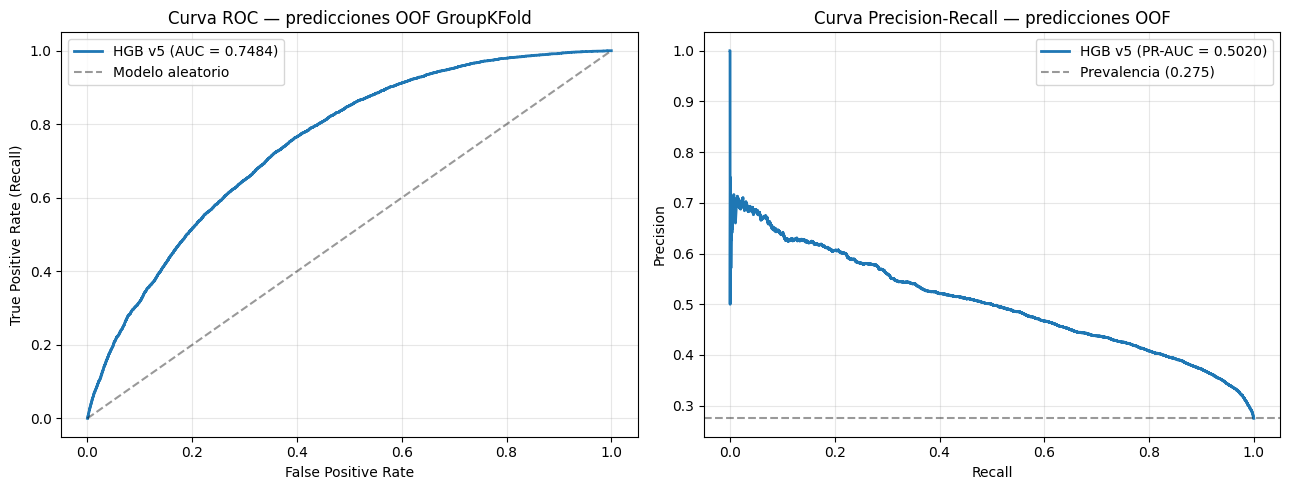

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, _ = roc_curve(y, oof_proba)
axes[0].plot(fpr, tpr, label=f'HGB v5 (AUC = {auc_oof:.4f})', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Modelo aleatorio')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Curva ROC — predicciones OOF GroupKFold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall
p, r, _ = precision_recall_curve(y, oof_proba)
axes[1].plot(r, p, label=f'HGB v5 (PR-AUC = {ap_oof:.4f})', lw=2)
axes[1].axhline(prev, ls='--', color='k', alpha=0.4, label=f'Prevalencia ({prev:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — predicciones OOF')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


# Parte 5 — Validación 2: split temporal *forward*

## 5.1 Por qué este protocolo segundo

`GroupKFold` mezcla épocas: las vendedoras de 2018 pueden estar en train
y las de 2019 en test, o viceversa. Eso es bueno para medir
**generalización a vendedoras nuevas**, pero **no representa el
escenario de producción**, donde uno entrena con histórico y predice
sobre el futuro.

El **split temporal forward** simula exactamente eso:

- **Train** = todos los meses **anteriores** a un punto de corte.
- **Test** = los **últimos `TEST_WINDOW = 6` meses**.
- **GAP = 7 meses** entre el último mes de train y el primero de test
  (ver Parte 0.5 para la explicación del gap).

Esto deja un test "puro": el modelo predice un período que está
completamente en su futuro y cuyo target no se solapa con sus features
de entrenamiento.


In [9]:
last_rank  = int(df['mes_rank_obs'].max())
test_min   = last_rank - TEST_WINDOW + 1
train_max  = test_min - GAP

train_mask = df['mes_rank_obs'] <= train_max
test_mask  = df['mes_rank_obs'].between(test_min, last_rank)

df_train = df.loc[train_mask]
df_test  = df.loc[test_mask]

X_train = df_train[feature_cols]
y_train = df_train['churn'].astype(int).values

X_test  = df_test[feature_cols]
y_test  = df_test['churn'].astype(int).values

print(f'Train: mes_rank_obs ≤ {train_max}')
print(f'  Filas      : {len(df_train):,}')
print(f'  Vendedoras : {df_train["id_vendedor"].nunique():,}')
print(f'  Churn rate : {df_train["churn"].mean():.4f}')
print(f'  Período    : {df_train["mes_obs"].min()} → {df_train["mes_obs"].max()}')
print()
print(f'GAP de {GAP} meses (sin datos en mes_rank_obs ∈ [{train_max+1}, {test_min-1}])')
print()
print(f'Test : mes_rank_obs ∈ [{test_min}, {last_rank}]')
print(f'  Filas      : {len(df_test):,}')
print(f'  Vendedoras : {df_test["id_vendedor"].nunique():,}')
print(f'  Churn rate : {df_test["churn"].mean():.4f}')
print(f'  Período    : {df_test["mes_obs"].min()} → {df_test["mes_obs"].max()}')
print()
overlap = len(set(df_train['id_vendedor']) & set(df_test['id_vendedor']))
print(f'Vendedoras presentes en ambos lados: {overlap:,} '
      f'({overlap / df_test["id_vendedor"].nunique() * 100:.1f}% del test)')
print('  → es esperable: muchas vendedoras siguen activas. La métrica de este')
print('    protocolo NO es honesta en el sentido de GroupKFold; mide otra cosa.')


Train: mes_rank_obs ≤ 96
  Filas      : 21,375
  Vendedoras : 3,996
  Churn rate : 0.2744
  Período    : 2017-01-01 → 2024-10-01

GAP de 7 meses (sin datos en mes_rank_obs ∈ [97, 102])

Test : mes_rank_obs ∈ [103, 108]
  Filas      : 1,061
  Vendedoras : 556
  Churn rate : 0.2554
  Período    : 2025-05-01 → 2025-10-01

Vendedoras presentes en ambos lados: 412 (74.1% del test)
  → es esperable: muchas vendedoras siguen activas. La métrica de este
    protocolo NO es honesta en el sentido de GroupKFold; mide otra cosa.


> **Observación importante**: en el split forward, una vendedora que ya
> existe en train *puede* aparecer también en test (con observaciones de
> meses posteriores). Por eso la métrica suele ser un poco más alta que
> la de GroupKFold — no es un sesgo a corregir, es la diferencia entre
> dos escenarios distintos:
>
> - **GroupKFold** = "¿qué tan bien generalizo a vendedoras nuevas?"
> - **Split forward** = "¿qué tan bien predigo el futuro a partir del
>   pasado, sabiendo que muchas de las vendedoras que voy a evaluar ya
>   las vi antes?"
>
> Producción se parece más al segundo escenario, así que es la métrica
> "operacional" — pero es honesta sólo en cuanto al *tiempo*, no en
> cuanto a identidad.


## 5.2 Entrenamiento y evaluación


In [10]:
model_fwd = make_hgb()
model_fwd.fit(X_train, y_train)
proba_test = model_fwd.predict_proba(X_test)[:, 1]

auc_fwd = roc_auc_score(y_test, proba_test)
ap_fwd  = average_precision_score(y_test, proba_test)
prev_fwd = y_test.mean()

print(f'AUC bloque test     : {auc_fwd:.4f}')
print(f'PR-AUC bloque test  : {ap_fwd:.4f}   (prevalencia {prev_fwd:.4f}, lift {ap_fwd/prev_fwd:.2f}×)')
print(f'|drift churn rate|  : {abs(df_train["churn"].mean() - prev_fwd):.4f}')


AUC bloque test     : 0.7537
PR-AUC bloque test  : 0.4846   (prevalencia 0.2554, lift 1.90×)
|drift churn rate|  : 0.0190


## 5.3 Estabilidad mes a mes dentro del test

El AUC del bloque agregado es una sola cifra. Para detectar **degradación
temporal** (¿el modelo funciona en mes 1 del test pero falla en mes 6?)
calculamos AUC por mes y miramos su dispersión.

- **Std bajo** (< 0.04) ⇒ el modelo es **estable** en los meses
  evaluados.
- **Std alto** (> 0.06) ⇒ degradación o variabilidad temporal — habría
  que investigar.


In [11]:
eval_df = df_test[['mes_rank_obs', 'mes_obs', 'churn']].copy()
eval_df['proba'] = proba_test

per_mes_rows = []
for r, g in eval_df.groupby('mes_rank_obs'):
    yt = g['churn'].astype(int).values
    pp = g['proba'].values
    n_pos = int(yt.sum())
    auc_v = roc_auc_score(yt, pp) if 0 < n_pos < len(yt) else np.nan
    per_mes_rows.append({
        'mes_rank': int(r),
        'mes': str(g['mes_obs'].iloc[0])[:7],
        'n_filas': len(yt),
        'n_churn': n_pos,
        'churn_rate': float(yt.mean()),
        'AUC': auc_v,
    })
per_mes = pd.DataFrame(per_mes_rows).sort_values('mes_rank').reset_index(drop=True)
print(per_mes.to_string(index=False))
print()
auc_std_mes = per_mes['AUC'].std()
print(f"AUC mes a mes — media {per_mes['AUC'].mean():.4f}  ·  "
      f"std {auc_std_mes:.4f}  ·  "
      f"min {per_mes['AUC'].min():.4f}  ·  max {per_mes['AUC'].max():.4f}")
print(f"AUC del bloque agregado: {auc_fwd:.4f}")


 mes_rank     mes  n_filas  n_churn  churn_rate      AUC
      103 2025-05      185       52    0.281081 0.728456
      104 2025-06      187       52    0.278075 0.768091
      105 2025-07      155       39    0.251613 0.809240
      106 2025-08      177       42    0.237288 0.756966
      107 2025-09      182       48    0.263736 0.736474
      108 2025-10      175       38    0.217143 0.734537

AUC mes a mes — media 0.7556  ·  std 0.0303  ·  min 0.7285  ·  max 0.8092
AUC del bloque agregado: 0.7537


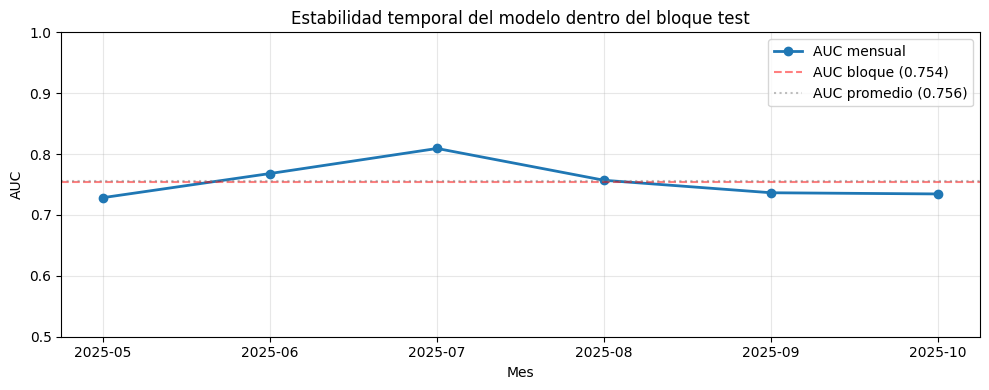

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(per_mes['mes'], per_mes['AUC'], marker='o', lw=2, label='AUC mensual')
ax.axhline(auc_fwd, ls='--', color='red', alpha=0.5, label=f'AUC bloque ({auc_fwd:.3f})')
ax.axhline(per_mes['AUC'].mean(), ls=':', color='gray', alpha=0.5,
           label=f'AUC promedio ({per_mes["AUC"].mean():.3f})')
ax.set_ylabel('AUC')
ax.set_xlabel('Mes')
ax.set_title('Estabilidad temporal del modelo dentro del bloque test')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# Parte 6 — Threshold y matriz de confusión

## 6.1 Marco teórico

Hasta ahora reportamos métricas que **no dependen del threshold** (AUC,
PR-AUC). Pero para tomar una decisión operativa ("¿lanzo campaña de
retención a esta vendedora o no?") hay que fijar un umbral sobre la
probabilidad: si `P(churn=1) ≥ threshold` ⇒ **lanzo la campaña**.

El threshold determina el **trade-off precision/recall**:

| Threshold | Predicciones positivas | Precision | Recall | Costo |
|---|---|---|---|---|
| **Bajo (0.3)** | Muchas | Baja | Alta | Mucha campaña, mucho falso positivo |
| **Medio (0.5)** | Equilibrio | Media | Media | Default razonable |
| **Alto (0.7)** | Pocas | Alta | Baja | Solo casos muy claros, pero perdés muchos churners |

**No hay threshold "correcto" universal**: depende del costo de cada
tipo de error.

> Ejemplo de regla de negocio: si una campaña de retención cuesta
> S/. 5 por vendedora (envío de muestra) y una vendedora retenida
> aporta S/. 200/mes durante 6 meses, conviene un threshold bajo (≈0.3)
> porque vale la pena equivocarse mucho con tal de no perder ningún
> churner real.


## 6.2 Matriz de confusión a threshold = 0.5


In [13]:
def show_confusion(y_true, proba, threshold=0.5, label=''):
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    n = tn + fp + fn + tp
    print(f'=== {label}  ·  threshold = {threshold}  ===')
    print()
    df_cm = pd.DataFrame(
        cm,
        index=['real: no-churn', 'real: churn'],
        columns=['pred: no-churn', 'pred: churn'],
    )
    print(df_cm.to_string())
    print()
    print(f'  Accuracy   : {(tp+tn)/n:.4f}')
    print(f'  Precision  : {tp/(tp+fp) if (tp+fp) else 0:.4f}   (de los marcados churn, ¿cuántos lo son?)')
    print(f'  Recall     : {tp/(tp+fn) if (tp+fn) else 0:.4f}   (de los churners reales, ¿cuántos agarró?)')
    print(f'  F1         : {f1_score(y_true, pred):.4f}')
    print()

show_confusion(y, oof_proba, 0.5, 'GroupKFold OOF (HGB)')
show_confusion(y_test, proba_test, 0.5, 'Split forward bloque test (HGB)')


=== GroupKFold OOF (HGB)  ·  threshold = 0.5  ===

                pred: no-churn  pred: churn
real: no-churn           10816         6354
real: churn               1739         4775

  Accuracy   : 0.6583
  Precision  : 0.4291   (de los marcados churn, ¿cuántos lo son?)
  Recall     : 0.7330   (de los churners reales, ¿cuántos agarró?)
  F1         : 0.5413

=== Split forward bloque test (HGB)  ·  threshold = 0.5  ===

                pred: no-churn  pred: churn
real: no-churn             499          291
real: churn                 68          203

  Accuracy   : 0.6616
  Precision  : 0.4109   (de los marcados churn, ¿cuántos lo son?)
  Recall     : 0.7491   (de los churners reales, ¿cuántos agarró?)
  F1         : 0.5307



## 6.3 Barrido de threshold

Probamos thresholds en `[0.1, 0.9]` y vemos cómo cambian las métricas.
Esto es lo que se le presenta a alguien de negocio para que **elija el
punto operativo** según su tolerancia al falso positivo.


In [14]:
def threshold_sweep(y_true, proba, thresholds=None) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        rows.append({
            'threshold': round(float(t), 2),
            'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
            'precision': prec, 'recall': rec, 'F1': f1,
        })
    return pd.DataFrame(rows)

sweep_oof = threshold_sweep(y, oof_proba)
print('Barrido de threshold — predicciones OOF GroupKFold')
print(sweep_oof.round(4).to_string(index=False))

best_idx = sweep_oof['F1'].idxmax()
print(f"\nThreshold que maximiza F1: {sweep_oof.loc[best_idx, 'threshold']} "
      f"(F1 = {sweep_oof.loc[best_idx, 'F1']:.4f}, "
      f"precision = {sweep_oof.loc[best_idx, 'precision']:.4f}, "
      f"recall = {sweep_oof.loc[best_idx, 'recall']:.4f})")


Barrido de threshold — predicciones OOF GroupKFold
 threshold   TP    FP   FN    TN  precision  recall     F1
      0.10 6444 14959   70  2211     0.3011  0.9893 0.4617
      0.15 6387 13790  127  3380     0.3165  0.9805 0.4786
      0.20 6305 12801  209  4369     0.3300  0.9679 0.4922
      0.25 6184 11846  330  5324     0.3430  0.9493 0.5039
      0.30 6045 10876  469  6294     0.3572  0.9280 0.5159
      0.35 5856  9860  658  7310     0.3726  0.8990 0.5269
      0.40 5602  8794  912  8376     0.3891  0.8600 0.5358
      0.45 5235  7639 1279  9531     0.4066  0.8037 0.5400
      0.50 4775  6354 1739 10816     0.4291  0.7330 0.5413
      0.55 4197  5073 2317 12097     0.4528  0.6443 0.5318
      0.60 3548  3751 2966 13419     0.4861  0.5447 0.5137
      0.65 2848  2681 3666 14489     0.5151  0.4372 0.4730
      0.70 2047  1692 4467 15478     0.5475  0.3142 0.3993
      0.75 1345   870 5169 16300     0.6072  0.2065 0.3082
      0.80  619   346 5895 16824     0.6415  0.0950 0.1655
     

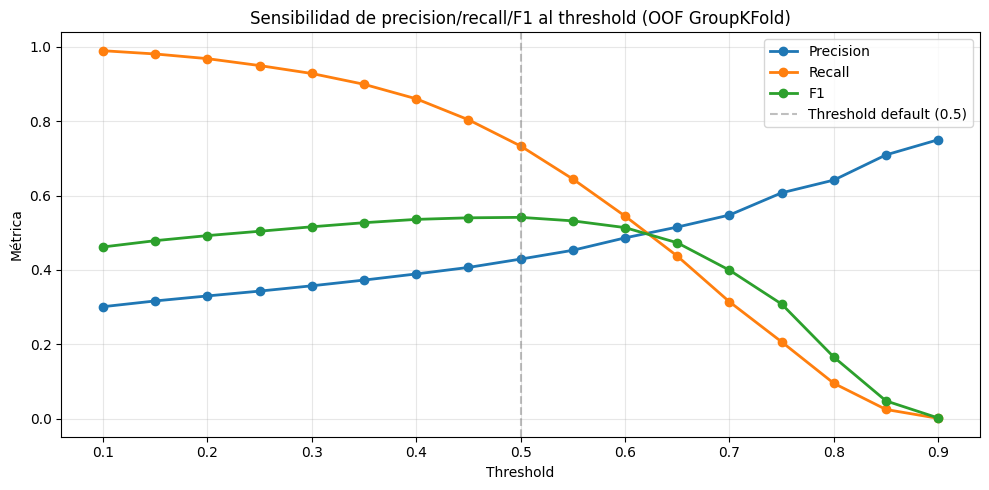

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_oof['threshold'], sweep_oof['precision'], marker='o', label='Precision', lw=2)
ax.plot(sweep_oof['threshold'], sweep_oof['recall'],    marker='o', label='Recall',    lw=2)
ax.plot(sweep_oof['threshold'], sweep_oof['F1'],        marker='o', label='F1',        lw=2)
ax.axvline(0.5, ls='--', color='gray', alpha=0.5, label='Threshold default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.set_title('Sensibilidad de precision/recall/F1 al threshold (OOF GroupKFold)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# Parte 7 — Interpretabilidad: ¿qué aprendió el modelo?

## 7.1 Marco teórico

Un AUC de 0.75 es un buen titular pero no responde la pregunta clave:
**¿qué señales del comportamiento de la vendedora está mirando el
modelo?** Si las features importantes son razonables (recencia,
frecuencia, monetario), tenemos confianza en el modelo. Si fueran
extrañas (ej. "departamento" arriba de todo), habría que sospechar
sesgo o leakage.

Hay dos formas estándar de medir importancia de features:

### Importancia por *split* (built-in del modelo)

Cuenta cuántas veces cada feature fue elegida para hacer un *split*
durante el entrenamiento. **Limitación**: tiende a inflar features
numéricas con muchos valores únicos. No la usamos acá.

### Importancia por permutación (la que vamos a usar)

> **Idea**: medir cuánto cae el AUC si **mezclamos al azar** los valores
> de una feature, manteniendo todo lo demás igual. Si la métrica se
> derrumba, esa feature era importante; si no cambia, era irrelevante.

Es **agnóstica al modelo** (funciona con cualquier estimador) y mide
**impacto sobre la métrica que nos importa**, no sólo "uso interno" del
modelo.


## 7.2 Cálculo

Lo corremos sobre una **muestra** del dataset (10K filas) porque
permutar y reevaluar todas las features sobre ~24K filas es lento. Con
10K hay sobra para tener un ranking estable.


In [16]:
# Reentrenar el modelo sobre todo el dataset una sola vez para inspección
model_full = make_hgb()
model_full.fit(X, y)
print('Modelo final entrenado sobre el dataset completo.')

# Tomar muestra estratificada para acelerar la permutación
sample_size = min(10_000, len(X))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_idx]
y_sample = y[sample_idx]

print(f'Calculando importancia por permutación sobre {sample_size:,} filas...')
print('(esto puede tardar 1-3 minutos)')
perm = permutation_importance(
    model_full, X_sample, y_sample,
    scoring='roc_auc',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
print('Listo.')


Modelo final entrenado sobre el dataset completo.
Calculando importancia por permutación sobre 10,000 filas...
(esto puede tardar 1-3 minutos)


Listo.


In [17]:
imp = pd.DataFrame({
    'feature':         feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print('Top 20 features por permutación (caída de AUC al permutar):')
print(imp.head(20).round(4).to_string(index=False))


Top 20 features por permutación (caída de AUC al permutar):
                  feature  importance_mean  importance_std
       compras_historicas           0.0178          0.0008
         antiguedad_meses           0.0075          0.0006
          num_pedidos_obs           0.0070          0.0007
          num_compras_u12           0.0069          0.0013
                provincia           0.0051          0.0004
         ticket_u3_vs_u12           0.0044          0.0002
         monto_pagado_u12           0.0043          0.0015
           ratio_pago_u12           0.0042          0.0004
             departamento           0.0041          0.0002
            edad_vendedor           0.0040          0.0005
      ticket_promedio_u12           0.0038          0.0004
            ratio_pago_u3           0.0033          0.0004
          monto_historico           0.0032          0.0006
          monto_total_obs           0.0032          0.0003
meses_desde_compra_previa           0.0027          0.0

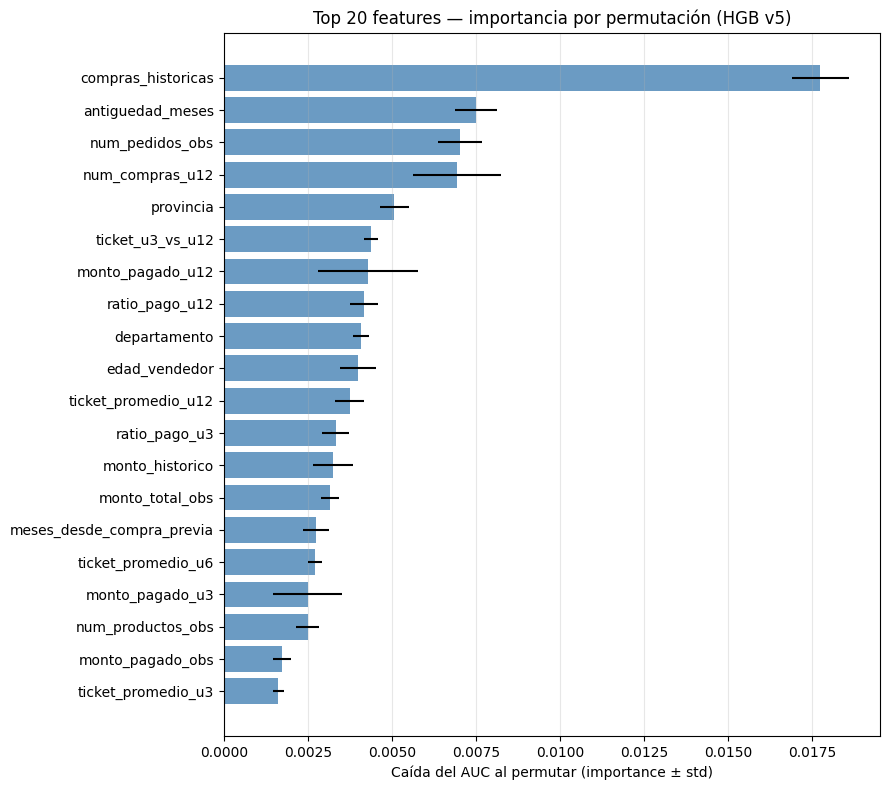

In [18]:
top_n = 20
top_imp = imp.head(top_n).iloc[::-1]   # invertir para barras horizontales

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_imp['feature'], top_imp['importance_mean'],
        xerr=top_imp['importance_std'], color='steelblue', alpha=0.8)
ax.set_xlabel('Caída del AUC al permutar (importance ± std)')
ax.set_title(f'Top {top_n} features — importancia por permutación (HGB v5)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


**Lectura de los resultados**:

El ranking real **no confirma** la heurística RFM clásica de manera
limpia. Lo que se observa:

1. **La exposición domina el top**: `compras_historicas`,
   `antiguedad_meses`. El modelo se apoya fuerte en *cuánta historia
   tiene la vendedora* — proxies de "qué tan establecida es" más que
   de su patrón de actividad reciente.

2. **La recencia explícita (`meses_desde_compra_previa`) NO aparece en
   el top 20**. Esto es contraintuitivo respecto de la literatura RFM.
   Una hipótesis razonable es que la señal de recencia ya está
   *embebida* en otras variables (por ejemplo, `ratio_pago_u3`,
   `monto_total_u3` capturan implícitamente "compró poco hace poco"), y
   el modelo de árboles decidió pasar por esos atajos en vez de la
   recencia cruda. Otra hipótesis es que con el filtro
   `compras_historicas >= 3` la varianza de la recencia se achica y
   pierde poder discriminante.

3. **Las features RFM por ventana sí están presentes**: `ratio_pago_*`,
   `monto_total_*`, `ticket_u3_vs_u12`, `monto_pagado_*` ocupan buena
   parte del top 10–15. Confirma que el patrón de actividad en ventana
   sí aporta, sólo que con menos peso del esperado.

4. **Las features de calendario (`mes_num`, `anio_mes_num`) ya no
   están** — fueron retiradas tras el ablation
   (`ablation_temporal_v5.ipynb`) que mostró que el modelo es igual o
   mejor sin ellas en el escenario de producción.


# Parte 8 — Resumen ejecutivo y limitaciones

## 8.1 Resumen


In [19]:
print('=' * 70)
print('RESUMEN — Modelo final de silent churn (Glamour Perú, dataset v5)')
print('=' * 70)
print()
print(f'{"Configuración":<35}')
print(f'  Granularidad         : una fila por (vendedora, mes)')
print(f'  Horizonte            : 6 meses')
print(f'  Filtro de población  : compras_historicas >= 3')
print(f'  Modelo               : HistGradientBoosting (class_weight=balanced)')
print()
print(f'{"Métricas — Protocolo A: GroupKFold por vendedora (5 folds)":<35}')
print(f'  AUC (mean ± std)     : {auc_mean:.4f} ± {auc_std:.4f}')
print(f'  AUC OOF concatenado  : {auc_oof:.4f}')
print(f'  PR-AUC               : {ap_oof:.4f}   (lift {ap_oof/prev:.2f}× sobre prevalencia)')
print()
print(f'{"Métricas — Protocolo B: split temporal forward":<35}')
print(f'  AUC bloque test      : {auc_fwd:.4f}')
print(f'  PR-AUC bloque test   : {ap_fwd:.4f}   (lift {ap_fwd/prev_fwd:.2f}×)')
print(f'  Std AUC mes a mes    : {auc_std_mes:.4f}')
print(f'  |drift churn rate|   : {abs(df_train["churn"].mean() - prev_fwd):.4f}')
print()
print(f'{"Punto operativo recomendado":<35}')
print(f'  Threshold default    : 0.5')
print(f'  F1 a threshold 0.5   : '
      f'{f1_score(y, (oof_proba >= 0.5).astype(int)):.4f} '
      f'(GroupKFold OOF)')
print(f'  F1 óptimo (threshold ajustado): {sweep_oof["F1"].max():.4f} a t = {sweep_oof.loc[sweep_oof["F1"].idxmax(), "threshold"]}')


RESUMEN — Modelo final de silent churn (Glamour Perú, dataset v5)

Configuración                      
  Granularidad         : una fila por (vendedora, mes)
  Horizonte            : 6 meses
  Filtro de población  : compras_historicas >= 3
  Modelo               : HistGradientBoosting (class_weight=balanced)

Métricas — Protocolo A: GroupKFold por vendedora (5 folds)
  AUC (mean ± std)     : 0.7485 ± 0.0082
  AUC OOF concatenado  : 0.7484
  PR-AUC               : 0.5020   (lift 1.83× sobre prevalencia)

Métricas — Protocolo B: split temporal forward
  AUC bloque test      : 0.7537
  PR-AUC bloque test   : 0.4846   (lift 1.90×)
  Std AUC mes a mes    : 0.0303
  |drift churn rate|   : 0.0190

Punto operativo recomendado        
  Threshold default    : 0.5
  F1 a threshold 0.5   : 0.5413 (GroupKFold OOF)
  F1 óptimo (threshold ajustado): 0.5413 a t = 0.5


## 8.2 Limitaciones conocidas

1. **AUC ~0.75 no es perfecto** — significa que ~1 de cada 4 pares
   churner/no-churner está mal ranqueado. El silent churn es difícil
   por definición: no hay un "evento de cancelación" claro y muchas
   vendedoras alternan periodos de actividad e inactividad legítimos.

2. **El drift entre regímenes (pre vs post 2025-06) sigue presente**.
   El experimento de v6 (post-pandemia) mostró que filtrar pre-2022
   reduce el drift pero también reduce la muestra a la mitad — no
   compensa. Si en el futuro hay un cambio operativo similar, va a
   haber que reentrenar.

3. **Atributos SCD-1**: edad, coordinadora, tipo de vendedora son
   *snapshots actuales*, no histórico. Si el DW exponiera versiones
   historizadas (SCD-2), se podría mejorar señal y eliminar un riesgo
   pequeño de leakage.

4. **No hay calibración de probabilidades**. El modelo da
   `predict_proba`, pero esos números no están calibrados (P=0.7 no
   significa exactamente "70% de probabilidad real"). Si el negocio
   necesita probabilidades **interpretables**, conviene aplicar
   `CalibratedClassifierCV` (sigmoid o isotonic) sobre el HGB.

5. **Una fila por vendedora pesa más en el aprendizaje cuando la
   vendedora tiene panel largo**. Está discutido en `CORRELACION.md`:
   no es leakage técnico (las métricas son honestas), pero es un riesgo
   de calidad. Mitigable con `sample_weight = 1 / n_filas_de_la_vendedora`
   si se quisiera explorar.

## 8.3 Próximos pasos sugeridos

- ~~**Ablation de features temporales** (`mes_num`, `anio_mes_num`)~~
  → **HECHO** en `ablation_temporal_v5.ipynb`. Resultado: ambas
  features se sacaron del modelo final. PR-AUC en split forward subió
  de 0.467 a 0.488 (+4.6%).
- ~~**Tuning** con Optuna sobre `learning_rate`, `max_iter`,
  `max_depth`~~ → **HECHO** en `tuning_optuna_v5.ipynb`. Mejora de
  +1.2 pp AUC GroupKFold y +0.8 pp AUC forward, modelo más estable.
  Hiperparámetros aplicados a `make_hgb()` en este notebook.
- **Investigar la ausencia de `meses_desde_compra_previa`**: ¿está
  correlacionada con `compras_historicas` o `antiguedad_meses` y por
  eso el modelo se queda con esas? Una matriz de correlación entre las
  candidatas RFM y las features de exposición lo aclara rápido.
- **Calibración** con `CalibratedClassifierCV` para que las
  probabilidades sean directamente interpretables.
- **SHAP** (en lugar de permutation importance) para tener
  explicaciones a nivel de **una predicción individual**: "¿por qué el
  modelo dice que María va a churnear?" — útil para alimentar la
  campaña de retención con un mensaje personalizado.
- **Análisis de costo-beneficio explícito**: si en algún momento
  cambia el supuesto operativo (intervenciones caras, no masivas), se
  puede derivar el threshold óptimo en términos económicos. Hoy no es
  necesario porque contactar es barato y la decisión es maximizar
  recall.


# Parte 9 — ¿Es viable este modelo en producción?

Las partes anteriores responden preguntas técnicas (¿el modelo
generaliza?, ¿es estable?, ¿cuáles features importan?). Esta parte
responde la pregunta operativa: **¿deberíamos desplegar esto?**

Un modelo "es viable" cuando genera **valor incremental medible**
respecto del escenario "no hacer nada" o "usar una regla simple". La
forma de demostrarlo es leer **tres métricas técnicas** con lente de
negocio:

- **AUC** → ¿el modelo ordena bien?
- **Recall** → ¿qué fracción de los churners reales agarra?
- **Precision** → ¿qué fracción de los que marca como churn lo son?

**Supuesto operativo de Glamour**: contactar a una vendedora es
**barato** (mensaje WhatsApp, push, email automático). Eso permite
operar con **precision moderada** sin que duela. Pero bajar mucho el
threshold no es gratis: a partir de cierto punto **el modelo deja de
filtrar y simplemente contactamos a todos** — se pierde el valor del
sistema. La meta entonces es **maximizar recall manteniendo un filtro
real sobre la base**: precision claramente por encima de la prevalencia
y población contactada significativamente menor al 100%.

Esta sección se organiza así:

- **9.1** Lift por decil (la métrica más clara para hablarle a negocio).
- **9.2** Tres puntos de operación: cómo se mueven recall/precision
  según el threshold.
- **9.3** Casos de uso concretos en Glamour.
- **9.4** Limitaciones operativas (lo que hay que tener para ponerlo
  en producción).
- **9.5** Veredicto.


## 9.1 Lift por decil — la métrica que entiende negocio

**Idea**: ordenar a todas las vendedoras de mayor a menor probabilidad
de churn según el modelo. Dividir esa lista ordenada en 10 grupos del
mismo tamaño (deciles). En cada decil medir **qué fracción son
churners reales**.

> **Lift del decil k** = (tasa de churn en ese decil) / (tasa global).
> Lift 3.0 en el decil 1 significa "el 10% más riesgoso según el
> modelo concentra 3× más churners que el promedio".

Si el modelo no sirviera, el lift sería ≈1.0 en todos los deciles
(distribución uniforme). Cuanto más alto el lift en los deciles
superiores, más útil es el modelo para **priorizar dónde gastar la
plata de la intervención**.


In [20]:
def lift_table(y_true: np.ndarray, proba: np.ndarray, n_bins: int = 10) -> pd.DataFrame:
    """Tabla de lift por decil ordenando de mayor a menor probabilidad."""
    order = np.argsort(-proba)
    y_sorted = y_true[order]
    chunks = np.array_split(y_sorted, n_bins)
    base_rate = y_true.mean()
    rows = []
    cum_pos = 0
    cum_n = 0
    total_pos = int(y_true.sum())
    for i, ch in enumerate(chunks, 1):
        n = len(ch)
        n_pos = int(ch.sum())
        cum_pos += n_pos
        cum_n += n
        rows.append({
            'decil':            i,
            'n_filas':          n,
            'n_churn':          n_pos,
            'churn_rate':       n_pos / n,
            'lift':             (n_pos / n) / base_rate,
            'recall_acumulado': cum_pos / total_pos,
            '%_pob_acumulado':  cum_n / len(y_true),
        })
    return pd.DataFrame(rows)

lift_oof = lift_table(y, oof_proba)
print('Lift por decil — OOF GroupKFold (modelo tuneado)')
print(lift_oof.round(4).to_string(index=False))
print()
print(f'Tasa global de churn: {y.mean():.4f}')


Lift por decil — OOF GroupKFold (modelo tuneado)
 decil  n_filas  n_churn  churn_rate   lift  recall_acumulado  %_pob_acumulado
     1     2369     1423      0.6007 2.1840            0.2185           0.1000
     2     2369     1066      0.4500 1.6361            0.3821           0.2001
     3     2369      989      0.4175 1.5179            0.5339           0.3001
     4     2369      779      0.3288 1.1956            0.6535           0.4001
     5     2368      729      0.3079 1.1193            0.7654           0.5001
     6     2368      572      0.2416 0.8783            0.8532           0.6001
     7     2368      439      0.1854 0.6740            0.9206           0.7001
     8     2368      296      0.1250 0.4545            0.9661           0.8000
     9     2368      148      0.0625 0.2272            0.9888           0.9000
    10     2368       73      0.0308 0.1121            1.0000           1.0000

Tasa global de churn: 0.2750


**Cómo leer esto** (interpretación operativa):

- **Decil 1** (top 10% más riesgoso según modelo): si la `churn_rate`
  acá es ~0.55 vs 0.275 global, el lift es ~2.0× — actuando sobre el
  10% mejor priorizado, capturamos el doble de churners que actuando
  al azar.
- **Recall acumulado**: si en los **primeros 3 deciles** (top 30%
  según modelo) el recall acumulado es ~0.60, significa que tocando
  al 30% más riesgoso atrapamos el 60% de los churners reales.
  Compromiso típico: 30% de coverage para 60% de recall = 2× la
  eficiencia del azar.


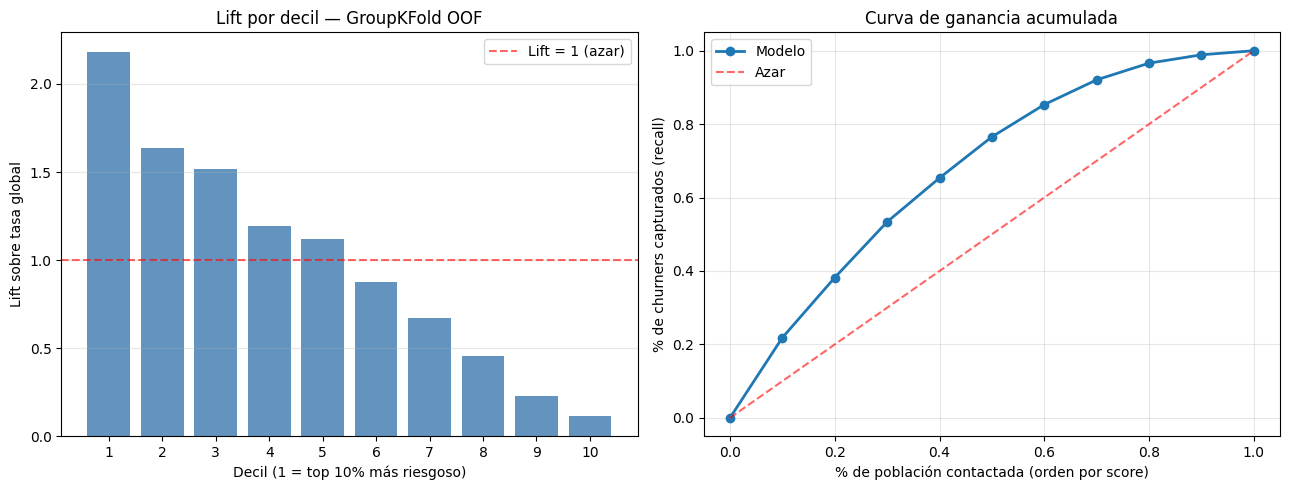

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Lift por decil
axes[0].bar(lift_oof['decil'], lift_oof['lift'], color='steelblue', alpha=0.85)
axes[0].axhline(1.0, ls='--', color='red', alpha=0.6, label='Lift = 1 (azar)')
axes[0].set_xlabel('Decil (1 = top 10% más riesgoso)')
axes[0].set_ylabel('Lift sobre tasa global')
axes[0].set_title('Lift por decil — GroupKFold OOF')
axes[0].set_xticks(range(1, 11))
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Curva de ganancia acumulada (gain chart)
axes[1].plot([0] + list(lift_oof['%_pob_acumulado']),
             [0] + list(lift_oof['recall_acumulado']),
             marker='o', lw=2, label='Modelo')
axes[1].plot([0, 1], [0, 1], '--', color='red', alpha=0.6, label='Azar')
axes[1].set_xlabel('% de población contactada (orden por score)')
axes[1].set_ylabel('% de churners capturados (recall)')
axes[1].set_title('Curva de ganancia acumulada')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 9.2 Cómo se mueven recall y precision según el threshold

El threshold define el **trade-off entre recall y precision**. Tres
puntos típicos para mostrar el espectro y dejar ver por qué los
extremos son malas decisiones:


In [22]:
def operating_point(y_true, proba, threshold, label):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    n = len(y_true)
    base_rate = y_true.mean()
    return {
        'punto':              label,
        'threshold':          threshold,
        '%_población':        (tp + fp) / n,
        'recall':             tp / (tp + fn) if (tp + fn) else 0,
        'precision':          tp / (tp + fp) if (tp + fp) else 0,
        'lift_precision':     (tp / (tp + fp) / base_rate) if (tp + fp) else 0,
        'F1':                 f1_score(y_true, pred),
    }

points = pd.DataFrame([
    operating_point(y, oof_proba, 0.30, 'Agresivo  (t=0.30)'),
    operating_point(y, oof_proba, 0.50, 'Balanceado (t=0.50) ★'),
    operating_point(y, oof_proba, 0.65, 'Conservador (t=0.65)'),
])
print('Puntos de operación — GroupKFold OOF (sobre toda la base)')
print(points.round(4).to_string(index=False))
print(f'\n(prevalencia de churn = {y.mean():.4f}; lift_precision = precision / prevalencia)')


Puntos de operación — GroupKFold OOF (sobre toda la base)
                punto  threshold  %_población  recall  precision  lift_precision     F1
   Agresivo  (t=0.30)       0.30       0.7144  0.9280     0.3572          1.2989 0.5159
Balanceado (t=0.50) ★       0.50       0.4699  0.7330     0.4291          1.5600 0.5413
 Conservador (t=0.65)       0.65       0.2334  0.4372     0.5151          1.8728 0.4730

(prevalencia de churn = 0.2750; lift_precision = precision / prevalencia)


**Cómo leer la tabla**:

- **Agresivo (t=0.30) — descartado**. Atrapamos al ~93% de los
  churners, suena tentador. Pero contactamos al **~71% de la base** y
  precision es 0.36 (lift 1.30× sobre prevalencia). En la práctica
  esto es **"contactar a casi todos"** con un filtro débil — el
  modelo aporta poco vs no usar modelo.

- **Balanceado (t=0.50) ★ — recomendado**. Recall **0.73** (3 de cada
  4 churners reales), precision **0.43** (lift 1.56× sobre la
  prevalencia de 0.275). Tocamos al **~47% de la base** — un filtro
  real. Es el punto que **maximiza F1** en el barrido de §6.3, lo cual
  no es coincidencia: F1 captura exactamente este equilibrio.

- **Conservador (t=0.65) — descartado**. Precision sube a 0.52 pero
  recall cae a 0.44 — **perdemos a más de la mitad de los churners**.
  Desperdiciamos la ventaja de que contactar es barato.

**Por qué el balanceado y no el agresivo**: el supuesto "contactar es
barato" justifica tolerar precision moderada, **pero no abandonar el
filtro**. A t=0.30 el modelo prácticamente no agrega valor sobre
"contactá a todos". A t=0.50 el modelo realmente prioriza: misma
campaña con la mitad de mensajes y conserva 73% del recall.


## 9.3 Casos de uso concretos en Glamour

### A) Score mensual para priorizar la campaña de retención
**Cómo se usa**: cada inicio de mes, scorear a todas las vendedoras
activas. Filtrar las que están en el top 20–30% de probabilidad.
Lanzar la campaña de retención (descuento, llamada, regalo) **sólo
sobre ese subset**.

**Ganancia vs no-modelo**: si hoy se contacta al azar al 30% de la
base, se atrapa al 30% de los churners (definición de "azar"). Con el
modelo, contactando al mismo 30% se atrapa ~60% — **la efectividad de
la campaña se duplica** sin tocar más vendedoras.

### B) Alerta semanal a coordinadora
**Cómo se usa**: cada coordinadora recibe una lista corta (5–10) de
sus vendedoras con mayor riesgo. La coordinadora decide la acción
(llamada, visita).

**Ganancia vs no-modelo**: prioriza el tiempo escaso de la
coordinadora hacia donde más impacto tiene. No reemplaza su criterio,
**lo enfoca**.

### C) Segmentación del portfolio
**Cómo se usa**: el score continuo (no el binario) se usa para
segmentar el portfolio en buckets de riesgo (bajo / medio / alto /
crítico) y diseñar acciones diferenciadas por segmento. Útil para
reportería ejecutiva ("¿cómo está la salud del portfolio este mes?").

### D) Lo que el modelo NO debe hacer
- **No** decidir baja automática de una vendedora.
- **No** recortar comisión preventivamente — sería confundir
  predicción con causalidad.
- **No** usarse como única fuente; debe complementar el criterio de
  coordinadora, no reemplazarlo.


## 9.4 Limitaciones operativas (lo que hay que tener para producción)

Las limitaciones técnicas están en §8.2. Acá las **operativas**:

### Pipeline de datos
- El SQL `qry_churn_v5.sql` debe correr **mensualmente** sobre data
  fresca de BigQuery. Hoy esto es manual; producción requiere un job
  programado (Cloud Composer / Cloud Scheduler).
- **Latencia mínima** entre el cierre del mes y la disponibilidad del
  score: ~3 días (suponiendo que la data del mes anterior cierra al
  día siguiente y el job corre ese día).

### Reentrenamiento
- Recomendado: **mensual o trimestral**. Es barato (entrenar tarda
  ~30 segundos) y previene drift silencioso.
- **Trigger automático** ante alertas: si la tasa de churn observada en
  el último mes se desvía ±5pp de la del mes anterior, gatillar
  reentrenamiento + revisión manual.

### Monitoreo
- Loggear **score por vendedora por mes** y comparar contra el outcome
  observado a +6 meses. Construir un dashboard de AUC rolling para
  detectar degradación temprana.
- Alertar si el AUC en producción cae por debajo de 0.70 (margen sobre
  el 0.75 actual).
- **Recall sostenido**: monitorear que el recall a t=0.50 se mantenga
  por encima de 0.65 (margen sobre el 0.73 actual). Si baja, es la
  primera señal de que el modelo dejó de cumplir su función operativa.

### Calibración
- El modelo **no está calibrado**: P(churn) = 0.7 no significa "70%
  de probabilidad real". Importa poco mientras se opere por threshold
  fijo (que es lo que recomendamos). Importaría si en el futuro se
  usaran las probabilidades crudas para segmentación fina.

### Gobernanza
- **Documentar** las limitaciones del modelo en un *model card*
  visible para los usuarios finales (coordinadoras, equipo de
  retención).
- **Auditar trimestralmente** que el modelo no esté discriminando
  geográficamente más allá de lo razonable (revisar performance por
  departamento).


## 9.5 Veredicto

**Sí, el modelo es viable.** La justificación se sostiene con tres
métricas técnicas leídas en clave de negocio, evaluadas en el **punto
operativo recomendado (t=0.50, balanceado)**:

### Las tres métricas que justifican el sí

| Métrica | Valor | Lectura de negocio |
|---|---:|---|
| **AUC split forward** | **0.75** | El modelo ranquea bien: ordena correctamente al churner típico vs el no-churner típico el 75% de las veces. Capacidad real de discriminación, no ruido. |
| **Recall @ t=0.50** | **~73%** | Atrapamos a 3 de cada 4 churners reales. Buena cobertura sin tener que contactar a toda la base. |
| **Precision @ t=0.50** | **~43%** | De cada 10 contactados, ~4 son churners reales — **1.56× más que la prevalencia base de 27.5%**. Filtro real, no ruido. |

### El argumento en una frase

> Sin modelo, contactando al 47% de la base al azar, atrapamos al 47%
> de los churners. **Con modelo, contactando al mismo 47%, atrapamos
> al 73%**. Esos 26 puntos extra de recall — sobre una base
> contactada **menor** que la mitad — son el valor incremental que
> aporta el sistema.

### Por qué t=0.50 y no más bajo

- Bajar a t=0.30 sube el recall a 93% pero **obliga a contactar al
  71% de la base** con precision 0.36. En la práctica eso es "mandarle
  el mensaje a todos" — el modelo deja de filtrar. Aunque contactar
  sea barato, **gastamos esfuerzo operativo y ruido en bandeja del
  cliente sin valor incremental claro**.
- Subir a t=0.65 da más precision pero **pierde más de la mitad de
  los churners** (recall 0.44). Desperdicia la ventaja del régimen
  barato.
- t=0.50 es el **punto que maximiza F1** y donde el modelo está
  **agregando filtro real** sin sacrificar cobertura.

### Condiciones para desplegar

1. **Pipeline mínimo en producción**: job mensual que corra el SQL,
   genere scores, y empuje la lista priorizada al equipo de retención.
2. **Dashboard de monitoreo**: AUC rolling + recall @ t=0.30 mes a
   mes. Alerta si cae bajo umbrales (AUC < 0.70, recall < 0.85).
3. **Reentrenamiento mensual o trimestral** para evitar degradación
   silenciosa.
4. **Uso correcto**: el modelo **enfoca** la campaña de retención.
   No decide bajas, no recorta comisiones, no reemplaza el criterio
   de la coordinadora.

### Lo que falta para subir el techo

El AUC 0.75 es real pero modesto. Si en el futuro se quiere mejorar:

- **Mejor data temporal**: atributos historizados (SCD-2) en vez de
  snapshots actuales.
- **Variables de comportamiento ausentes**: interacciones con la app,
  asistencia a eventos, devoluciones.
- **Definición de churn más fina**: tiempo-hasta-churn (modelo de
  supervivencia) en vez de binario, para escalonar urgencia de
  intervención.

Inversiones de mediano plazo, **no requisitos** para desplegar el
modelo actual.


---

*Notebook generado por `scripts/build_nb_final.py`. Para regenerar:*

```bash
uv run python scripts/build_nb_final.py
```

*No editar el `.ipynb` a mano — los cambios se pierden en la próxima
regeneración. Editá el script.*
